# Capstone Project: Breast Cancer Risk Prediction


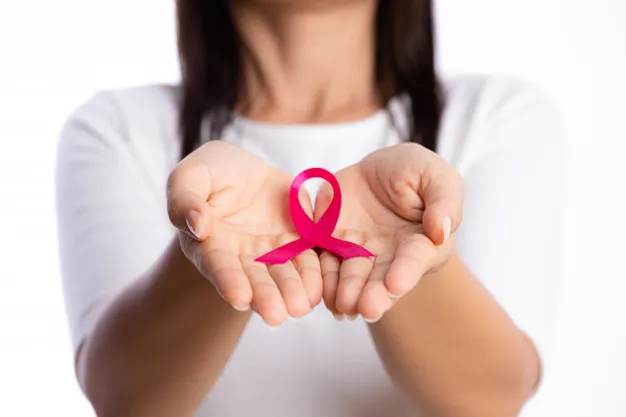

### Overview

This project aims to deepen the understanding of breast cancer survival trends and enhance prediction models for patient outcomes. By leveraging advanced statistical techniques and machine learning, the project seeks to analyze survival rates and accurately predict the 10-year mortality risk for breast cancer patients. The ultimate objective is to improve treatment planning, patient counseling, and overall cancer care strategies.


### Benefits:
Treatment Optimization: The models will help identify factors influencing breast cancer survival, allowing for more targeted and personalized treatment approaches.
Patient Counselling: Accurate prediction of 10-year mortality risk can assist in providing patients with more precise prognosis information.
Research Direction: Understanding survival patterns can guide future research efforts in breast cancer treatment and prevention.

### Install packages

In [ ]:
%%capture
!pip install lifelines

### Import Libraries




In [ ]:
import pandas as pd                    # Standard libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import KaplanMeierFitter   # Survival analysis
from lifelines import CoxPHFitter

from sklearn.model_selection import train_test_split,GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor

from IPython.display import display, HTML
import ipywidgets as widgets

# Evaluation
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')
sns.set_style("dark")
plt.style.use("dark_background")
plt.rcParams['font.family'] = 'DejaVu Sans'


### Read Dataset

In [ ]:
df = pd.read_csv("Breast Cancer METABRIC.csv")  #Load metabric breast cancer data
print("Dataset shape:", df.shape)

### Dataset Basic Information

In [ ]:
pd.set_option("display.max_columns", 100)         # Display basic info
df.head()

In [ ]:
print("\nDataset info:")
print(df.info())

##Inference
---
Patient ID: Unique identifier for each patient.

Age at Diagnosis: Age of the patient when diagnosed with cancer.

Type of Breast Surgery: The type of surgery performed on the breast, such as mastectomy or lumpectomy.

Cancer Type: General classification of the cancer type (e.g., invasive ductal carcinoma).

Cancer Type Detailed: More specific classification of the cancer type.

Cellularity: The degree of cellularity of the tumor, often used in pathology to describe the proportion of cells versus other components in a tissue sample.

Chemotherapy: Indicates whether the patient received chemotherapy (Yes/No).

Pam50 + Claudin-low subtype: Subtypes based on gene expression profiling, including Pam50 and Claudin-low classifications.

Cohort: The group or study cohort to which the patient belongs.

ER status measured by IHC: Estrogen receptor status as measured by Immunohistochemistry (IHC) (e.g., positive or negative).

ER Status: Estrogen receptor status (e.g., positive, negative).

Neoplasm Histologic Grade: Histologic grade of the neoplasm, indicating how much the tumor cells differ from normal cells.

HER2 status measured by SNP6: HER2 (human epidermal growth factor receptor 2) status measured by SNP (single nucleotide polymorphism) analysis.

HER2 Status: HER2 receptor status (e.g., positive, negative).

Tumor Other Histologic Subtype: Other histologic subtypes of the tumor not covered by main classifications.

Hormone Therapy: Indicates whether the patient received hormone therapy (Yes/No).

Inferred Menopausal State: Menopausal state inferred based on age and clinical criteria (e.g., premenopausal, postmenopausal).

Integrative Cluster: Classification based on integrative clustering of genomic data.

Primary Tumor Laterality: The side of the body where the primary tumor is located (left or right).

Lymph nodes examined positive: Number of lymph nodes that tested positive for cancer.

Mutation Count: Total number of genetic mutations identified in the tumor.

Nottingham prognostic index: Prognostic score based on tumor size, lymph node status, and histologic grade.

Oncotree Code: A code that represents the type of cancer based on the OncoTree classification.

Overall Survival (Months): The overall survival time of the patient in months.

Overall Survival Status: Indicates whether the patient is alive or deceased.

PR Status: Progesterone receptor status (e.g., positive, negative).

Radio Therapy: Indicates whether the patient received radiotherapy (Yes/No).

Relapse Free Status (Months): Time in months the patient remained free from cancer relapse.

Relapse Free Status: Indicates whether the patient has had a relapse of cancer (Yes/No).

Sex: The sex of the patient (male or female).

3-Gene classifier subtype: Subtypes based on the expression of three specific genes.

Tumor Size: Size of the primary tumor.

Tumor Stage: Stage of the tumor, indicating the extent of cancer spread.

Patient's Vital Status: Indicates whether the patient is alive or deceased at the last follow-up.

In [ ]:
null_percent = (df.isnull().mean() * 100).sort_values(ascending=False)        # Check missing values
print("\nMissing values percentage:\n",null_percent)

In [ ]:
df.describe().T

### Drop Irrelevant Features

In [ ]:
drop_cols = [                                                            # Columns to drop
    "Patient ID", "Cancer Type", "Cohort", "ER status measured by IHC",
    "HER2 status measured by SNP6","PR Status","Relapse Free Status (Months)",
    "Relapse Free Status", "Patient's Vital Status"
]

df = df.drop(columns=[col for col in drop_cols if col in df.columns])      # Remove specified columns
print(f"\nDataset shape after dropping columns: {df.shape}")

### Inference:

---


Removed Features:

Patient ID – non-predictive unique identifiers

Cancer Type – all same value

Cohort- Metadata column

ER status measured by IHC - redundant with ER Status

HER2 status measured by SNP6 - redundant with HER2 Status

PR Status - redundant with ER Status

Relapse Free Status (Months) - Alternative outcome variable

Relapse Free Status - Alternative outcome variable

Patient's Vital Status-To avoid data leakage

### Categorical and Numerical columns

In [ ]:
cols_to_convert = ["Neoplasm Histologic Grade", "Tumor Stage"]       # Convert to categorical
df[cols_to_convert] = df[cols_to_convert].astype("category")

num_cols = df.select_dtypes(include=["int64", "float64"]).columns     # Separate numeric and categorical columns
cat_cols = df.select_dtypes(include=["object", "category"]).columns

In [ ]:
df[num_cols] = df[num_cols].fillna(df[num_cols].median())   # Median imputation for numerical cols
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])     # Mode imputation for categorical cols

print(f"\nRemaining missing values: {df.isnull().sum().sum()}")

In [ ]:
num_cols

In [ ]:
cat_cols

### Data Visualization

### Univariate analysis:


In [ ]:
plt.figure(figsize=(15, 10))

colors = sns.color_palette("Purples", 12)[4:]

for i, col in enumerate(num_cols[:6]):     # Loop through first 6 numerical columns to create subplots
    plt.subplot(2, 3, i+1)

    sns.histplot(             # Plot histogram with KDE (density curve)
        df[col],              # Data column
        bins=30,              # Number of bins
        kde=True,             # Smooth density curve
        color=colors[i],
        edgecolor="white",
        alpha=0.9,
        line_kws={'color': 'white', 'linewidth': 2}
    )

    plt.title(col, fontsize=11, fontweight='bold', color='white')
    plt.xlabel("")
    plt.ylabel("")
    plt.xticks(rotation=0, color='white')
    plt.yticks(color='white')

plt.suptitle("Distribution of Numerical Features", fontsize=16, fontweight='bold', color='white')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Inference

---


Univariate analysis is the process of analyzing a single variable at a time to understand its distribution, central tendency, spread, and patterns.

Age at Diagnosis: The distribution is slightly right-skewed, with the highest number of patients diagnosed between the ages of 50 and 70.

Lymph nodes examined positive: The distribution is heavily right-skewed, with the vast majority of patients having zero positive lymph nodes.

Mutation Count: The distribution is heavily right-skewed, showing that most patients have a low mutation count, with a long tail toward higher counts.

Nottingham prognostic index: The distribution is roughly bell-shaped and slightly right-skewed, centered around a moderate index value of 3 to 4.

Overall Survival (Months): The distribution is heavily right-skewed, with a peak between 100 and 150 months, indicating most patients have long survival.

Tumor Size: The distribution is right-skewed, with the highest frequency of patients having smaller tumor sizes, typically between 20 and 30 mm.

### Outlier Treatment

In [ ]:
#Outlier Treatment
df['Tumor Size'] = np.log1p(df['Tumor Size'])
df['Mutation Count'] = np.log1p(df['Mutation Count'])
df['Tumor Size'] = df['Tumor Size'].clip(upper=df['Tumor Size'].quantile(0.99))

### Infrence

---


Log transformation compresses the right-skewed distributions of Tumor Size
and Mutation Count, making them more normally distributed.

Capping at the 99th percentile sets any extreme Tumor Size values to the 99th percentile threshold, removing the impact of outliers.

Both features become more suitable for machine learning models by reducing skewness and limiting the influence of extreme values.

In [ ]:
selected_cols = [                  # Clinically important categorical features
    'ER Status',
    'HER2 Status',
    'Chemotherapy',
    'Hormone Therapy',
    'Tumor Stage',
    'Neoplasm Histologic Grade'
]

plt.figure(figsize=(14, 10))

for i, col in enumerate(selected_cols):
    plt.subplot(3, 2, i+1)

    order = df[col].value_counts().index
    palette = sns.color_palette("Purples", len(order) + 4)[4:]

    ax = sns.countplot(           # Count plot for categorical distribution
        data=df,
        x=col,
        hue=col,
        order=order,
        palette=palette,
        legend=False
    )

    max_height = max([p.get_height() for p in ax.patches])

    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width()/2,
            height + max_height * 0.03,
            f'{int(height)}',
            ha='center',
            fontsize=9,
            fontweight='bold',
            color='white'
        )

    ax.set_ylim(0, max_height * 1.2)

    plt.title(col, fontsize=12, fontweight='bold', color='white')

    plt.xticks(rotation=0, fontsize=9, color='white')
    plt.yticks(rotation=0, color='white')

    plt.xlabel("")
    plt.ylabel("Count", fontsize=10, color='white')

plt.suptitle(
    "Key Clinical Feature Distributions",
    fontsize=16,
    fontweight='bold',
    color='white'
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Inference

---


ER Status: Positive (1865) and Negative (644) with a total count of 2509.

Chemotherapy: Yes (412) and No (2097) with a total count of 2509.

Tumor Stage: Stage 2 (1700), Stage 1 (630), Stage 3 (144), Stage 0 (24),  Stage 4 (11) with a total count of 2509.

HER2 Status: Negative (2262) and Positive (247) with a total count of 2509.

Hormone Therapy: Yes (1745) and No (764) with a total count of 2509.

Neoplasm Histologic Grade: Grade 3 (1319), Grade 2 (976), Grade 1 (214) with a total count of 2509.

### Bivariate Analysis

In [ ]:
features = ['ER Status', 'HER2 Status', 'Chemotherapy', 'Hormone Therapy']  # Important treatment and biomarker-related features

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.flatten(), features):

    order = df[feature].value_counts().index
    palette = sns.color_palette("Purples", len(order) + 4)[4:]

    sns.barplot(                # Bar plot showing median survival for each category
        data=df,
        x=feature,                           # Categorical feature
        y='Overall Survival (Months)',       # Continuous outcome (used for analysis)
        estimator=np.median,
        order=order,
        palette=palette,
        ax=ax
    )

    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2,
            height + 0.5,
            f'{height:.0f}',
            ha='center',
            fontsize=10,
            fontweight='bold',
            color='white'
        )

    ax.set_title(feature, fontsize=12, fontweight='bold', color='white')
    ax.set_ylabel("Median Survival", fontsize=11, fontweight='bold', color='white')
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=0, labelsize=10, colors='white')
    ax.tick_params(axis='y', labelsize=10, colors='white')

plt.suptitle(
    "Median Overall Survival by Clinical Feature",
    fontsize=16,
    fontweight='bold',
    color='white'
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Inference

---


Plot represents bivariate analysis as it examines how individual clinical
features influence survival duration using median-based comparisons.”

ER Status: Both ER Positive and ER Negative patients have the same median overall survival of 116.

Chemotherapy: Patients who did not receive chemotherapy have a higher median survival (116) compared to those who did (84).

HER2 Status: HER2 Negative patients have a higher median survival (116) compared to HER2 Positive patients (87).

Hormone Therapy: Patients who did not receive hormone therapy have a higher median survival (126) compared to those who did (116) — meaning no hormone therapy is associated with longer survival.

## Encoding

In [ ]:
ordinal_mapping = {                           # Define ordinal mappings for ordered categorical features
    'Neoplasm Histologic Grade': {1: 1, 2: 2, 3: 3},
    'Cellularity': {'Low': 1, 'Moderate': 2, 'High': 3}
}

for col, mapping in ordinal_mapping.items():     # Apply ordinal encoding
    if col in df.columns:
        df[col] = df[col].map(mapping)

if 'Tumor Stage' in df.columns:              # Convert Tumor Stage to integer
    df['Tumor Stage'] = df['Tumor Stage'].astype(float).astype(int)

binary_cols = ['Chemotherapy', 'Hormone Therapy', 'Radio Therapy', 'Sex', 'Inferred Menopausal State']
for col in binary_cols:                  # Convert binary categorical features into numerical form (0/1)
    if col in df.columns:
        df[col] = df[col].map({'Yes': 1, 'No': 0, 'Female': 1, 'Male': 0, 'Pre': 0, 'Post': 1})

binary_positive_negative_cols = ['HER2 Status', 'ER Status']
for col in binary_positive_negative_cols:           # Encode receptor status columns (Positive/Negative → 1/0)
    if col in df.columns:
        df[col] = df[col].map({'Positive': 1, 'Negative': 0})

nominal_cols = ['Type of Breast Surgery', 'Cancer Type Detailed', 'Tumor Other Histologic Subtype',
                'Pam50 + Claudin-low subtype', 'Integrative Cluster', 'Primary Tumor Laterality',
                'Oncotree Code', '3-Gene classifier subtype']  # Select nominal (unordered categorical) columns for one-hot encoding

nominal_cols = [col for col in nominal_cols if col in df.columns]  # Keep only existing columns
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)   # Apply one-hot encoding (drop_first=True to avoid multicollinearity)


### Inference

---


Ordinal features such as Neoplasm Histologic Grade and Cellularity are encoded based on their natural order, preserving the inherent ranking information.
Tumor Stage is converted into integer format to ensure proper numerical interpretation.
Binary categorical variables (e.g., Chemotherapy, Hormone Therapy, ER Status, HER2 Status) are mapped to 0 and 1, enabling efficient model processing.
Nominal variables with no inherent order are handled using one-hot encoding.

In [ ]:
df["Overall Survival Status"] = df["Overall Survival Status"].replace({       # Convert survival status to binary
    "Living": 0,
    "Deceased": 1
})

This converts the "Overall Survival Status" column to binary format, where 0 represents "Living" and 1 represents "Deceased".

### Survival Analysis

### Kaplan–Meier Survival Curve

In [ ]:
kmf = KaplanMeierFitter()
kmf.fit(                                            # Fit KM model
    durations=df["Overall Survival (Months)"],
    event_observed=df["Overall Survival Status"]
)

time_point = 120                           # Get survival probability at 120 months
surv_10yr = kmf.predict(time_point)

plt.figure(figsize=(10, 6))
kmf.plot(ci_show=True)
plt.axvline(x=time_point, color='red', linestyle='--', label='10 Years (120 months)')
plt.axhline(y=surv_10yr, color='blue', linestyle='--', label=f'Survival @120m = {surv_10yr:.2f}')
plt.scatter(time_point, surv_10yr, color='black', zorder=5)
plt.text(
    time_point + 5,
    surv_10yr,
    f"{surv_10yr:.2f}",
    fontsize=10,
    verticalalignment='center'
)

plt.title("Kaplan-Meier Survival Curve (10-Year Highlight)")
plt.xlabel("Time (Months)")
plt.ylabel("Survival Probability")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Inference

---

A Kaplan-Meier estimator is fitted using survival time and event status (0=Living, 1=Deceased) as input. The model predicts the survival probability at 120 months (10 years). The plot shows the stepwise KM survival curve with 95% confidence intervals (shaded area). A red vertical line marks 120 months, a blue horizontal line shows the predicted survival probability at that time point, and a black point indicates the exact intersection. The plot provides a clear visualization of how survival probability declines over time, with specific focus on the 10-year survival rate.

In [ ]:
survival_10yr = kmf.predict(120)
print("10-year survival probability:", survival_10yr)

mortality_10yr = 1 - survival_10yr
print("10-year mortality probability:", mortality_10yr)

Out of all patients, only about 44% are expected to survive beyond 10 years, while more than half 56% may not survive past 10 years.

## Feature Selection

In [ ]:
df_vif = df.drop(columns=['Overall Survival Status', 'Overall Survival (Months)'])

X = df_vif.select_dtypes(include=['int64','float64']).copy()
# Select only numeric columns

vif_data = pd.DataFrame()       # Calculate VIF
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data.sort_values(by='VIF', ascending=False))

### Inference

---


VIF is used to detect multicollinearity among numerical features. Features with high VIF indicate redundancy and may be removed to improve model stability and interpretability. Sex shows extremely high multicollinearity with a VIF of 115.2, indicating it is highly correlated with other features and should be removed to avoid model instability. All other features have VIF values below 2, suggesting minimal multicollinearity among them.

In [ ]:
df = df.drop(columns=['Sex'])

### Cox Proportional Hazards Model

In [ ]:
cph = CoxPHFitter(penalizer=0.1)
cph.fit(df, duration_col="Overall Survival (Months)", event_col="Overall Survival Status")       # Fit Cox model with penalizer

significant_features = cph.summary[cph.summary['p'] < 0.05].index.tolist()                     # Drop non-significant features (p > 0.05)
df_final = df[significant_features + ["Overall Survival (Months)", "Overall Survival Status"]]

cph_final = CoxPHFitter(penalizer=0.1)
cph_final.fit(df_final, duration_col="Overall Survival (Months)", event_col="Overall Survival Status")   # Refit final Cox model
cph_final.print_summary()

### Inference

---


The model shows good discrimination with a concordance index of 0.66, and the log-likelihood ratio test (489.65 on 14 df) indicates the model is highly significant overall. Strongest Risk Factors: Older age at diagnosis (HR=1.02), mastectomy (HR=1.44), higher Nottingham prognostic index (HR=1.11), and Integrative Cluster_5 (HR=1.34) are associated with increased mortality risk. Protective Factors: ER Status positive (HR=0.77), claudin-low subtype (HR=0.77), Integrative Cluster_10 (HR=0.78), and right-sided tumors (HR=0.80) are associated with lower mortality risk.
Clinical Variables: Lymph nodes examined positive (HR=1.03), tumor size (HR=1.20), and tumor stage (HR=1.13) are all significant predictors of worse survival. Statistical Significance: All 14 features in the final model have p-values < 0.05, confirming their significant contribution to predicting overall survival in breast cancer patients.

In [ ]:
hr = cph_final.summary['exp(coef)']   # Extract hazard ratios (HR) from the fitted Cox model summary
features = hr.index

plt.figure(figsize=(10,6))         # Plot horizontal bar chart for HR
bars = plt.barh(features, hr, color='skyblue', edgecolor='black')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.02, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}', va='center', fontsize=10)

plt.xlabel("Hazard Ratio (HR)")
plt.title("Cox Model: Hazard Ratios for Significant Features")
plt.gca().invert_yaxis()  # highest HR on top
plt.tight_layout()
plt.show()

### Inference

---


Risk Factors: Features with HR > 1 increase mortality risk, with mastectomy (1.44), Integrative Cluster_5 (1.34), Integrative Cluster_8 (1.28), and menopausal state (1.23) showing the strongest effects.

Protective Factors: Features with HR < 1 reduce mortality risk, including claudin-low subtype (0.77), Integrative Cluster_10 (0.78), right-sided tumors (0.80), and Integrative Cluster_3 (0.82).

Clinical Variables: Traditional factors like tumor size (1.20), Nottingham prognostic index (1.11), and lymph node positivity (1.03) show modest but significant increased risk, while ER status (0.77) remains protective.

### Target Variable

In [ ]:
df_clean = df_final.copy()

df_clean = df_clean[                                           # Keep only valid 10-year outcomes
    (df_clean["Overall Survival (Months)"] >= 120) |
    (df_clean["Overall Survival Status"] == 1)
]

df_clean["death_10yr"] = (                                      #Creating target variable
    (df_clean["Overall Survival Status"] == 1) &
    (df_clean["Overall Survival (Months)"] <= 120)
).astype(int)

mortality_rate = df_clean["death_10yr"].mean()
print("10-year mortality rate:", mortality_rate)

The dataset is filtered to include only patients who either survived at least 120 months (10 years) or died within the follow-up period, ensuring valid 10-year outcome assessment. 10-Year Mortality Rate: Approximately 57.4% of patients in this filtered cohort died within 10 years, reflecting the mortality risk at the 10-year time point.

In [ ]:
X = df_clean.drop(columns=[
    "Overall Survival (Months)",
    "Overall Survival Status",
    "death_10yr"
])

y = df_clean["death_10yr"]

Features (X): All predictor variables except the survival time, survival status, and the newly created 10-year death indicator are used as input features. Target (y): The binary target variable death_10yr (1 if death occurred within 10 years, 0 otherwise).

## Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
print("Train mortality rate:", y_train.mean())
print("Test mortality rate:", y_test.mean())

The stratified split ensures both training and test sets have nearly identical 10-year mortality rates (~57.4%), maintaining class balance for reliable model evaluation.

In [ ]:
num_cols = ['Age at Diagnosis', 'Lymph nodes examined positive',       # Numeric columns for scaling
       'Nottingham prognostic index',
       'Tumor Size'
]

## Standard Scaler

In [ ]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

The numeric features are standardized using StandardScaler to have zero mean and unit variance, ensuring they contribute equally to models sensitive to feature scales.

In [ ]:
from sklearn.model_selection import StratifiedKFold
kfold = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

We use StratifiedKFold with 4 splits to ensure each fold maintains the same class distribution (57.4% mortality) for robust cross-validation.

# Logistic Regression

In [ ]:
lr = LogisticRegression(class_weight="balanced", max_iter=1000)    # Base Model

### Cross Validation



In [ ]:
scoring = ["accuracy", "roc_auc", "recall", "precision", "f1"]        # Scoring metrics for evaluation

lr_results = cross_validate(
    lr,
    X_train_scaled,
    y_train,
    cv=kfold,
    scoring=scoring,
    return_train_score=True
)

print("Accuracy:", lr_results['test_accuracy'].mean())
print("ROC-AUC:", lr_results['test_roc_auc'].mean())
print("Recall:", lr_results['test_recall'].mean())
print("Precision:", lr_results['test_precision'].mean())
print("F1-score", lr_results['test_f1'].mean())

### Model Training

In [ ]:
lr.fit(X_train_scaled, y_train)

### Predictions

In [ ]:
log_pred_lr = lr.predict(X_test_scaled)        # Predict class labels
log_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

### Model Evaluation

In [ ]:
print("=== Logistic Regression Evaluation ===")
log_acc = accuracy_score(y_test, log_pred_lr)
log_roc = roc_auc_score(y_test, log_prob_lr)
log_rec = recall_score(y_test, log_pred_lr)
log_prec = precision_score(y_test, log_pred_lr)
log_f1 = f1_score(y_test, log_pred_lr)

print(f"Accuracy : {log_acc:.3f}")
print(f"ROC-AUC  : {log_roc:.3f}")
print(f"Recall   : {log_rec:.3f}")
print(f"Precision: {log_prec:.3f}")
print(f"F1-score : {log_f1:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, log_pred_lr))

cm = confusion_matrix(y_test, log_pred_lr)         # Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Inference

---


Logistic Regression achieves moderate performance with 73% accuracy and a ROC-AUC of 0.78, serving as a solid baseline model.

Precision for death prediction is strong at 0.80, meaning when the model predicts death, it is correct 80% of the time.

Recall for death is 0.70, capturing 70% of actual deaths.

The model is relatively balanced with similar F1-scores for both classes (0.70 for survivors, 0.75 for deaths).

Logistic Regression is a good choice for interpretability and reliable predictions, offering a reasonable trade-off between precision and recall without overfitting.

# Decision Tree

In [ ]:
dt = DecisionTreeClassifier(
    criterion='gini',                 # The function to measure the quality of a split.
    max_depth=6,                      # Maximum depth of the tree.
    min_samples_split=2,              # Minimum number of samples required to split an internal node
    min_samples_leaf=5,               # Minimum number of samples required to be at a leaf node.
    class_weight="balanced",
    random_state=42                   # Ensures reproducible results across runs.
)

### Cross Validation

In [ ]:
scoring = ["accuracy", "roc_auc", "recall", "precision", "f1"]   # Metrics to evaluate

dt_results = cross_validate(
    dt,
    X_train,
    y_train,
    cv=kfold,
    scoring=scoring,
    return_train_score=True
)

print("Decision Tree CV Results:")
print("Accuracy:", dt_results['test_accuracy'].mean())
print("ROC-AUC:", dt_results['test_roc_auc'].mean())
print("Recall:", dt_results['test_recall'].mean())
print("Precision:", dt_results['test_precision'].mean())

### Hyperparameter Tuning

In [ ]:
scoring = ["accuracy", "roc_auc", "recall", "precision", "f1"]

param_grid_dt = {                            # Hyperparameter grid
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 20],          # Maximum depth of the tree
    'min_samples_split': [2, 10, 20],        # Minimum samples needed to split an internal node
    'min_samples_leaf': [1, 5, 10],          # Minimum samples required at a leaf node
    'class_weight': ['balanced', None]
}

grid_search_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),   # Base estimator
    param_grid=param_grid_dt,
    scoring=scoring,
    refit='recall',
    n_jobs=-1,                                           # Use all CPU cores
    cv=kfold,
    verbose=1
)

grid_search_dt.fit(X_train, y_train)
print("Best Decision Tree params:", grid_search_dt.best_params_)

### Cross-Validate

In [ ]:
scoring = ["accuracy", "roc_auc", "recall", "precision", "f1"]

best_dt = grid_search_dt.best_estimator_       # Decision Tree with the best recall from GridSearchCV

dt_results_best = cross_validate(
    best_dt,                            # Best decision tree from grid search
    X_train,                            # Training features
    y_train,                            # Training labels
    cv=kfold,                           # Stratified K-Fold CV
    scoring=scoring,
    return_train_score=True
)

print("Best DT CV Results:")
print("Accuracy:", dt_results_best['test_accuracy'].mean())
print("ROC-AUC:", dt_results_best['test_roc_auc'].mean())
print("Recall:", dt_results_best['test_recall'].mean())
print("Precision:", dt_results_best['test_precision'].mean())
print("F1-score:", dt_results_best['test_f1'].mean())

### Predictions

In [ ]:
tree_pred_dt = best_dt.predict(X_test)       # Make predictions on the test set
tree_prob_dt = best_dt.predict_proba(X_test)[:, 1]    # Predicted probabilities for the positive class (class 1)

### Evaluation

In [ ]:
print("=== Decision Tree Evaluation ===")
dt_acc = accuracy_score(y_test, tree_pred_dt)
dt_roc = roc_auc_score(y_test, tree_prob_dt)
dt_rec = recall_score(y_test, tree_pred_dt)
dt_prec = precision_score(y_test, tree_pred_dt)
dt_f1 = f1_score(y_test, tree_pred_dt)

print(f"Accuracy : {dt_acc:.3f}")
print(f"ROC-AUC  : {dt_roc:.3f}")
print(f"Recall   : {dt_rec:.3f}")
print(f"Precision: {dt_prec:.3f}")
print(f"F1-score : {dt_f1:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, tree_pred_dt))

cm = confusion_matrix(y_test, tree_pred_dt)         # Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Inference

---


Decision Tree achieves the highest recall (0.84) among all models, capturing 84% of patients who die within 10 years.

Precision for death is 0.71, meaning 29% of death predictions are false positives—a trade-off for achieving high sensitivity.

The model struggles with survivors, showing very low recall (0.54) for class 0, indicating it often misclassifies survivors as deaths.

ROC-AUC (0.79) is moderate, suggesting reasonable but not optimal class separation compared to Random Forest and SVM.

Decision Tree is ideal when maximizing detection of deaths is the priority, but should be avoided if accurately identifying survivors is equally important.

# Random Forest Model

In [ ]:
rfc = RandomForestClassifier(random_state=42)

### Hyperparameter Tuning

In [ ]:
param_grid_rf = {
    'n_estimators': [100, 300],              # Number of trees in the forest
    'max_features': ['sqrt', 'log2'],        # Number of features to consider when looking for best split
    'max_depth': [None, 10, 20],             # Maximum depth of each tree
    'min_samples_leaf': [1, 5],              # Minimum number of samples required to be at a leaf node
    'class_weight': ['balanced', 'balanced_subsample']
}

grid_search_rf = GridSearchCV(
    estimator=rfc,
    param_grid=param_grid_rf,           # Hyperparameters to search over
    scoring='recall',                   # Metric used to evaluate models during CV (focus on catching positive cases)
    n_jobs=-1,
    cv=kfold,                           # Use Stratified K-Fold cross-validation
    verbose=1                           # Print progress messages
)

grid_search_rf.fit(X_train, y_train)
print("Best Random Forest params:", grid_search_rf.best_params_)

### Model Training

In [ ]:
best_rf = RandomForestClassifier(**grid_search_rf.best_params_, random_state=42)   # Best parameters found in grid search
best_rf.fit(X_train, y_train)            # Fit the model to learn patterns from training data

### Predictions

In [ ]:
rf_pred_rf = best_rf.predict(X_test)         # Predict the class labels for the test set
rf_prob_rf = best_rf.predict_proba(X_test)[:, 1]    # Predict the probabilities for the positive class (death within 10 years)

### Evaluation

In [ ]:
print("=== Random Forest Evaluation ===")
rf_acc = accuracy_score(y_test, rf_pred_rf)
rf_roc = roc_auc_score(y_test, rf_prob_rf)
rf_rec = recall_score(y_test, rf_pred_rf)
rf_prec = precision_score(y_test, rf_pred_rf)
rf_f1 = f1_score(y_test, rf_pred_rf)

print(f"Accuracy : {rf_acc:.3f}")
print(f"ROC-AUC  : {rf_roc:.3f}")
print(f"Recall   : {rf_rec:.3f}")
print(f"Precision: {rf_prec:.3f}")
print(f"F1-score : {rf_f1:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred_rf))

cm = confusion_matrix(y_test, rf_pred_rf)              # Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Inference

---
Random Forest is the best overall model, achieving the highest accuracy (0.74) and ROC-AUC (0.82) among all models.

Recall (0.74) and precision (0.79) are well-balanced for death prediction, providing both good sensitivity and reliability.

The model performs equally well on both classes, with identical recall (0.74) for survivors and deaths, demonstrating balanced performance.

ROC-AUC of 0.82 indicates excellent discrimination, outperforming Logistic Regression (0.78) and Decision Tree (0.79).

Random Forest is the recommended model for clinical use, offering the best combination of accuracy, balance, and robust generalization.

# SVM Model

In [ ]:
base_svm = SVC(class_weight='balanced', probability=True, random_state=42)

scoring = ["accuracy", "roc_auc", "recall", "precision", "f1"]
base_svm_results = cross_validate(
    base_svm,
    X_train_scaled,              # Scaled training features
    y_train,                        # Target labels
    cv=kfold,
    scoring=scoring,
    return_train_score=True      # Returns training scores for comparison
)

print("Base SVM CV Results:")
print("Accuracy :", base_svm_results['test_accuracy'].mean())    # 'test_' refers to the validation (fold) scores
print("ROC-AUC  :", base_svm_results['test_roc_auc'].mean())
print("Recall   :", base_svm_results['test_recall'].mean())
print("Precision:", base_svm_results['test_precision'].mean())
print("F1 score:", base_svm_results['test_f1'].mean())

### Model Training and Predicting

In [ ]:
base_svm.fit(X_train_scaled, y_train)                       # Fit the base SVM model on scaled training data
svm_pred_svm = base_svm.predict(X_test_scaled)              # Predict class labels on scaled test data
svm_prob_svm = base_svm.predict_proba(X_test_scaled)[:, 1]  # Predict probabilities for the positive class

### Evaluation

In [ ]:
print("=== SVM Evaluation ===")
svm_acc = accuracy_score(y_test, svm_pred_svm)
svm_roc = roc_auc_score(y_test, svm_prob_svm)
svm_rec = recall_score(y_test, svm_pred_svm)
svm_prec = precision_score(y_test, svm_pred_svm)
svm_f1 = f1_score(y_test, svm_pred_svm)

print(f"Accuracy : {svm_acc:.3f}")
print(f"ROC-AUC  : {svm_roc:.3f}")
print(f"Recall   : {svm_rec:.3f}")
print(f"Precision: {svm_prec:.3f}")
print(f"F1-score : {svm_f1:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, svm_pred_svm))

cm = confusion_matrix(y_test, svm_pred_svm)          # Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Inference

---

SVM achieves the highest precision (0.85) for death prediction, making it the most reliable model when it predicts mortality.

ROC-AUC (0.81) is excellent, matching Random Forest and indicating strong class separation capability.

Recall for death is the lowest at 0.66, missing 34% of actual deaths due to its conservative prediction approach.

The model is highly effective at identifying survivors (recall 0.85), often correctly classifying patients who live beyond 10 years.

SVM is best suited when minimizing false positive death predictions is clinically critical, but not ideal when maximizing detection of all high-risk patients is the priority.

## ROC-AUC Curve

In [ ]:
plt.figure(figsize=(8,6))

models_probs = [                      # List of models with their predicted probabilities, names, and plot colors
    (log_prob_lr, "Logistic", "blue"),
    (svm_prob_svm, "SVM", "green"),
    (tree_prob_dt, "Decision Tree", "orange"),
    (rf_prob_rf, "Random Forest", "red")
]

for prob, name, color in models_probs:
    fpr, tpr, _ = roc_curve(y_test, prob)    # Compute False Positive Rate (FPR) and True Positive Rate (TPR) for ROC
    auc_score = roc_auc_score(y_test, prob)  # Compute Area Under Curve (AUC)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.3f})", color=color, lw=2)

plt.plot([0,1], [0,1], color='gray', linestyle='--', lw=2, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison", fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

### Inference

---


Random Forest achieves the highest AUC (0.815) , demonstrating superior ability to distinguish between patients who die within 10 years and those who survive.

SVM performs nearly as well (0.810) with a very similar ROC curve, showing strong discrimination despite lower accuracy.

All models outperform random guessing (diagonal line), confirming their clinical utility for predicting 10-year mortality.

The gap between Random Forest/SVM and Logistic Regression (0.815 vs 0.778) indicates ensemble and kernel methods capture more complex patterns than linear approaches.

Random Forest is the overall best performer for balanced classification, combining high ROC-AUC with strong accuracy and F1-score.

## Result Comparison

In [ ]:
models = ["Logistic Regression", "Decision Tree", "Random Forest", "SVM"]   # Models and predictions
preds = [log_pred_lr, tree_pred_dt, rf_pred_rf, svm_pred_svm]
probs = [log_prob_lr, tree_prob_dt, rf_prob_rf, svm_prob_svm]

accuracy = [accuracy_score(y_test, p) for p in preds]      # Calculate metrics
roc_auc = [roc_auc_score(y_test, pr) for pr in probs]
recall = [recall_score(y_test, p) for p in preds]
precision = [precision_score(y_test, p) for p in preds]
f1 = [f1_score(y_test, p) for p in preds]

purple_palette = sns.color_palette("Purples", 5)
colors = purple_palette
x = np.arange(len(models))
width = 0.15

plt.figure(figsize=(10,5))
bars1 = plt.bar(x - 2*width, accuracy, width, label="Accuracy", color=colors[1])
bars2 = plt.bar(x - width, roc_auc, width, label="ROC-AUC", color=colors[2])
bars3 = plt.bar(x, recall, width, label="Recall", color=colors[3])
bars4 = plt.bar(x + width, precision, width, label="Precision", color=colors[4])
bars5 = plt.bar(x + 2*width, f1, width, label="F1-score", color=colors[0])

for bars in [bars1, bars2, bars3, bars4, bars5]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.2f}",
                 ha='center', va='bottom', fontsize=9, color='white')

plt.xticks(x, models)
plt.ylabel("Score")
plt.ylim(0,1.05)
plt.title("METABRIC Models Comparison", fontsize=13, fontweight='bold')
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

### Inference

---


Random Forest is the best overall model, achieving the highest accuracy (0.74) and ROC-AUC (0.81) with balanced recall (0.74) and precision (0.79).

Decision Tree has the highest recall (0.84) , making it most effective at identifying patients who die within 10 years, though it has lower accuracy (0.71).

SVM has the highest precision (0.85) , making it most reliable when predicting death, but has the lowest recall (0.66), missing many true death cases.

Logistic Regression offers strong precision (0.80) with moderate recall (0.70), providing a balanced alternative.

Use Decision Tree for maximum sensitivity, SVM for maximum precision (fewest false alarms), or Random Forest for the best overall balanced performance.

In [ ]:
models = ["Logistic Regression", "Decision Tree", "Random Forest", "SVM"]          # Models and predictions
preds = [log_pred_lr, tree_pred_dt, rf_pred_rf, svm_pred_svm]

recall_scores = [recall_score(y_test, p) for p in preds]         # Calculate recall for each model
purple_palette = sns.color_palette("Purples", 5)[3]

plt.figure(figsize=(8,5))
bars = plt.bar(models, recall_scores, color=purple_palette)

for bar, score in zip(bars, recall_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{score:.2f}", ha='center', va='bottom', fontsize=10, color='white')

plt.ylim(0, 1.05)
plt.ylabel("Recall Score", fontsize=11)
plt.title("Model Comparison by Recall (METABRIC Dataset)", fontsize=13, fontweight='bold')
plt.grid(axis="y", alpha=0.3)
plt.show()

### Inference

---


Decision Tree achieves the highest recall (0.84) , significantly outperforming all other models in identifying patients who die within 10 years.

Random Forest follows with recall (0.74) , providing strong sensitivity while maintaining better overall balance.

Logistic Regression shows moderate recall (0.70) , positioned in the middle range of sensitivity performance.

SVM has the lowest recall (0.66) , indicating it captures the fewest true death cases among all four models.

The recall curve clearly separates models into tiers: Decision Tree as highest sensitivity, Random Forest and Logistic Regression in the middle, and SVM as lowest sensitivity.

### Predict

In [ ]:
# --- Section: Breast Cancer Prediction ---
display(HTML("<h2 style='color:#6A4C93;'>Breast Cancer Survival Prediction</h2>"))

def predict(features):   # Function to make a prediction based on user input
    return best_rf.predict(np.array(features).reshape(1, -1))

feature_names = [
    "Age at Diagnosis",
    "ER Status",
    "Inferred Menopausal State",
    "Lymph nodes examined positive",
    "Nottingham prognostic index",
    "Tumor Size",
    "Tumor Stage",
    "Type of Breast Surgery_Mastectomy",
    "Pam50 + Claudin-low subtype_claudin-low",
    "Integrative Cluster_10",
    "Integrative Cluster_3",
    "Integrative Cluster_5",
    "Integrative Cluster_8",
    "Primary Tumor Laterality_Right"
]


feature_widgets = [widgets.IntText(value=0, description=f'{feature}:') for feature in feature_names]  # Create input widgets


predict_button = widgets.Button(description="Predict", button_style='success')   # Create a button for making predictions


output_widget = widgets.Output()     # Output widget to display prediction

def on_button_click(b):                  # Function to handle button click event
    user_input = [int(widget.value) for widget in feature_widgets]
    prediction = predict(user_input)

    output_widget.clear_output()       # Clear previous output and display the prediction
    with output_widget:
        display(HTML(f"<h3 style='color:#D35400;'>Prediction (0=No Event, 1=Event): {prediction[0]}</h3>"))

predict_button.on_click(on_button_click)     # Attach the button click event

display(*feature_widgets, predict_button, output_widget)   # Display widgets and output area

### Best Regards!